# Foreground Modeling using Dynamic Mode Decomposition

This tutorial is inspired by the paper [Compressed dynamic mode decomposition for background modeling](https://arxiv.org/abs/1512.04205) by Erichson et al.

Author: Originally written by [Josh Myers-Dean](https://joshmyersdean.github.io/), modified for this course

Packages needed: **PyDMD**, NumPy, pandas, opencv-python, Matplotlib

## Data

We will use data from, [SegTrackV2](https://web.engr.oregonstate.edu/~lif/SegTrack2/dataset.html) from Oregon State. This is an older binary segmentation dataset that offers a good test bed for this method. We will use the `frog` video, which contains 240 frames of a frog jumping in a pond. The video is available in the `data/segmentation/frog` directory. We will also use the ground truth segmentation masks for this video, which are available in the `data/segmentation/groundtruth` directory.

In [1]:
from pydmd import CDMD, DMD
from pydmd.plotter import plot_eigs

import matplotlib.pyplot as plt
from matplotlib import style

plt.gray()
style.use("tableau-colorblind10")
from matplotlib import animation

from IPython.display import HTML

import os
import numpy as np
import pandas as pd

import cv2
from typing import Tuple

<Figure size 640x480 with 0 Axes>

We peek at the data to examine the amount of frames per object video. Note that the videos with small number frames will most likely have poor results.

## Methods needed for the tutorial
Below we define (and comment) some methods which we're going to use later on.

In [2]:
def get_video_dmd(
    noise: bool = False, noise_amt: float = 0.01
) -> Tuple[np.ndarray, Tuple[int, int]]:
    """
    Retreives a video in matrix format (i.e., each column is a frame)

    Parameters
    ----------
    noise :
      boolean to use noise or not
    noise_amt :
      standard deviation for noise ~ N(0, noise_amt)

    Returns
    -------
    Tuple:
      Matrix representation of the video
      Original shape of frame

    """
    imgs = []
    jpeg_dir = "../../data/segmentation/frog"
    shape = None
    for i in sorted(os.listdir(jpeg_dir)):
        tmp = cv2.imread(f"{jpeg_dir}/{i}", cv2.IMREAD_GRAYSCALE)
        shape = tmp.shape
        tmp = tmp.reshape(-1).astype(np.float32) / 255
        imgs.append(tmp)
    vid = np.vstack(imgs).T
    if noise:
        vid += np.random.normal(0, noise_amt, vid.shape)
        vid = vid.clip(0, 1)
    return vid, shape


def get_video() -> np.ndarray:
    """
    Retreives a video in tensor format (i.e., frames x heigh x width)

    Returns
    -------
    Numpy array:
      Tensor representation of the video

    """
    imgs = []
    jpeg_dir = "../../data/segmentation/frog"
    for i in sorted(os.listdir(jpeg_dir)):
        tmp = cv2.imread(f"{jpeg_dir}/{i}", cv2.IMREAD_GRAYSCALE)
        tmp = tmp.astype(np.float32) / 255
        imgs.append(tmp)
    return np.asarray(imgs)


def calc_iou(pred: np.ndarray, truth: np.ndarray, thresh: float = 0.1) -> float:
    """
    Helper method to calculate IoU for single frame

    Parameters
    ----------
    pred :
      background subtracted video
    truth :
      segmentation ground truth
    thresh :
      cut off for deciding if a pixel is foreground

    Returns
    -------
    float:
      IoU of  a frame

    """
    pred[pred < thresh] = 0
    pred[pred >= thresh] = 1
    intersection = np.logical_and(pred, truth).sum()
    union = np.logical_or(pred, truth).sum()
    return intersection / union if union > 0 else 0


def calc_miou(pred, truth, thresh=0.1) -> float:
    """
    Calculate average IoU for a video

    Parameters
    ----------
    pred :
      background subtracted video
    truth :
      segmentation ground truth
    thresh :
      cut off for deciding if a pixel is foreground

    Returns
    -------
    float:
      mIoU of  a video

    """
    assert pred.shape == truth.shape, "Pred and truth must be same shape"
    pred = pred.copy()
    miou = 0
    for i in range(pred.shape[0]):
        iou = calc_iou(pred[i, :, :], truth[i, :, :], thresh=thresh)
        miou += iou
    return miou / pred.shape[0]


def f1_score(y_true: np.ndarray, y_pred: np.ndarray, beta: int = 1) -> float:
    """
    Calculate F1 score.
    The original implmentation is written by Michal Haltuf on Kaggle.

    Parameters
    ----------
    y_true :
      segmentation ground truth

    y_pred :
      background subtracted video

    Returns
    -------
    float:
      f1 score of a video

    """

    tp = (y_true * y_pred).sum()
    tn = ((1 - y_true) * (1 - y_pred)).sum()
    fp = ((1 - y_true) * y_pred).sum()
    fn = (y_true * (1 - y_pred)).sum()

    epsilon = 1e-7

    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)

    f1 = (1 + beta**2) * (precision * recall)
    f1 /= beta**2 * precision + recall + epsilon
    return f1


def calc_f1(pred: np.ndarray, truth: np.ndarray, thresh: float = 0.1) -> float:
    """
    Calculate f1 score for a video

    Parameters
    ----------
    pred :
      background subtracted video
    truth :
      segmentation ground truth
    thresh :
      cut off for deciding if a pixel is foreground

    Returns
    -------
    float:
      f1 score of a video

    """
    assert pred.shape == truth.shape, "Pred and truth must be same shape"
    pred = pred.copy()
    truth = truth.copy()
    pred[pred < thresh] = 0
    pred[pred >= thresh] = 1
    pred = pred.astype(np.uint8)
    truth = truth.astype(np.uint8)
    return f1_score(truth.flatten(), pred.flatten())


def get_gt_video() -> np.ndarray:
    """
    Retreives a video of GT in tensor format (i.e., frames x heigh x width)

    Returns
    -------
    Numpy array:
      Tensor representation of the GT video

    """
    imgs = []
    jpeg_dir = "../../data/segmentation/frog"
    gt_dir = "../../data/segmentation/groundtruth/"
    jpeg_list = sorted(os.listdir(jpeg_dir))
    gt_list = sorted(os.listdir(gt_dir))
    valid = list(set(jpeg_list).intersection(set(gt_list)))
    for i in sorted(valid):
        tmp = f"{gt_dir}/{i}"
        tmp = cv2.imread(f"{gt_dir}/{i}", cv2.IMREAD_GRAYSCALE)
        tmp = tmp.astype(np.float32) / 255
        imgs.append(tmp)
    return np.asarray(imgs)


def play_video(interval: int = 10) -> None:
    """
    Helper function to play original video

    Parameters
    ----------
    interval :
      delay in ms between frames

    """
    video = get_video()

    fig = plt.figure()
    im = plt.imshow(video[0, :, :])

    plt.close()  # this is required to not display the generated image

    def init():
        im.set_data(video[0, :, :])

    def animate(i):
        im.set_data(video[i, :, :])
        return im

    anim = animation.FuncAnimation(
        fig, animate, init_func=init, frames=video.shape[0], interval=interval
    )
    return HTML(anim.to_html5_video())


def play_gt_video(interval: int = 10):
    """
    Helper function to play GT video

    Parameters
    ----------
    interval :
      delay in ms between frames

    """
    video = get_gt_video()

    fig = plt.figure()
    im = plt.imshow(video[0, :, :])

    plt.close()  # this is required to not display the generated image

    def init():
        im.set_data(video[0, :, :])

    def animate(i):
        im.set_data(video[i, :, :])
        return im

    anim = animation.FuncAnimation(
        fig, animate, init_func=init, frames=video.shape[0], interval=interval
    )
    return HTML(anim.to_html5_video())


def get_video_removed(video: np.ndarray, bg: np.ndarray) -> np.ndarray:
    """
    Helper function to subtract background from video

    Parameters
    ----------
    video :
      original video
    bg :
      background model

    Returns
    -------
    np.ndarray :
      predicted foreground

    """
    for i in range(video.shape[0]):
        video[i, :, :] -= bg
    return video


def play_video_removed(
    bg: np.ndarray,
    mask: bool = False,
    interval: int = 10,
    thresh: float = 0.1,
) -> None:
    """
    Helper function to play foreground video

    Parameters
    ----------
    bg :
      background model
    mask :
      Show binary version
    interval :
      delay in ms between frames
    thresh :
      value to decide if pixel is foreground

    """
    video = get_video()

    fig = plt.figure()
    subbed = video[0, :, :] - bg
    if mask:
        subbed[subbed > thresh] = 1
        subbed[subbed <= thresh] = 0
    else:
        subbed = subbed.clip(0, 1)
    im = plt.imshow(subbed)

    plt.close()  # this is required to not display the generated image

    def init():
        subbed = video[0, :, :] - bg
        if mask:
            subbed[subbed > thresh] = 1
            subbed[subbed <= thresh] = 0
        else:
            subbed = subbed.clip(0, 1)
        im.set_data(subbed)

    def animate(i):
        subbed = video[i, :, :] - bg
        if mask:
            subbed[subbed > thresh] = 1
            subbed[subbed <= thresh] = 0
        else:
            subbed = subbed.clip(0, 1)
        im.set_data(subbed)
        return im

    anim = animation.FuncAnimation(
        fig, animate, init_func=init, frames=video.shape[0], interval=interval
    )
    return HTML(anim.to_html5_video())

## Let's peek at the data

The parameter `interval` is the delay (in ms) between frames. For shorter videos, use a higher interval.

In [ ]:
play_video(interval=10)

In [ ]:
# show ground truth video
play_gt_video(interval=10)

## Fitting a DMD instance

Time to fit our video to (c)DMD, add noise, tinker with SVD rank, etc. We can also visualize our background model! Since we average the first `K` modes, we can visualize how our model changes wrt `K`. 

Recall that each column of our matrix will be a frame in the video and unless we have a long video, the system will be overdetermined. Note that in the paper the authors use an optimization scheme to decide on the number of modes; we are going to choose it emprically.

In [3]:
use_noise = False
noise = 0.01
video, shape = get_video_dmd(use_noise, noise)  # get video
print(f"Condition number of video matrix is {np.linalg.cond(video): .3f}")

Condition number of video matrix is  1346.151


In [4]:
comp = True  # use compressed DMD
svd_rank = 0  # rank=0 will automatically detect rank, try other values next!
optim = True  # Use optimized DMD
compression = ["linear", "sparse", "uniform", "sample"]
cmat = compression[2]  # compression matrix

if comp:
    dmd = CDMD(svd_rank=svd_rank, opt=optim, compression_matrix=cmat).fit(video)
else:
    dmd = DMD(svd_rank=svd_rank, opt=optim).fit(video)

In [5]:
modes = dmd.reconstructed_data.T.reshape(video.shape[1], shape[0], shape[1])

# Try changing the value of K, amount of modes we use
K = min(100, modes.shape[0])

modes = np.abs(modes)  # deal with complex values
bg = np.zeros_like(modes[0, :, :])

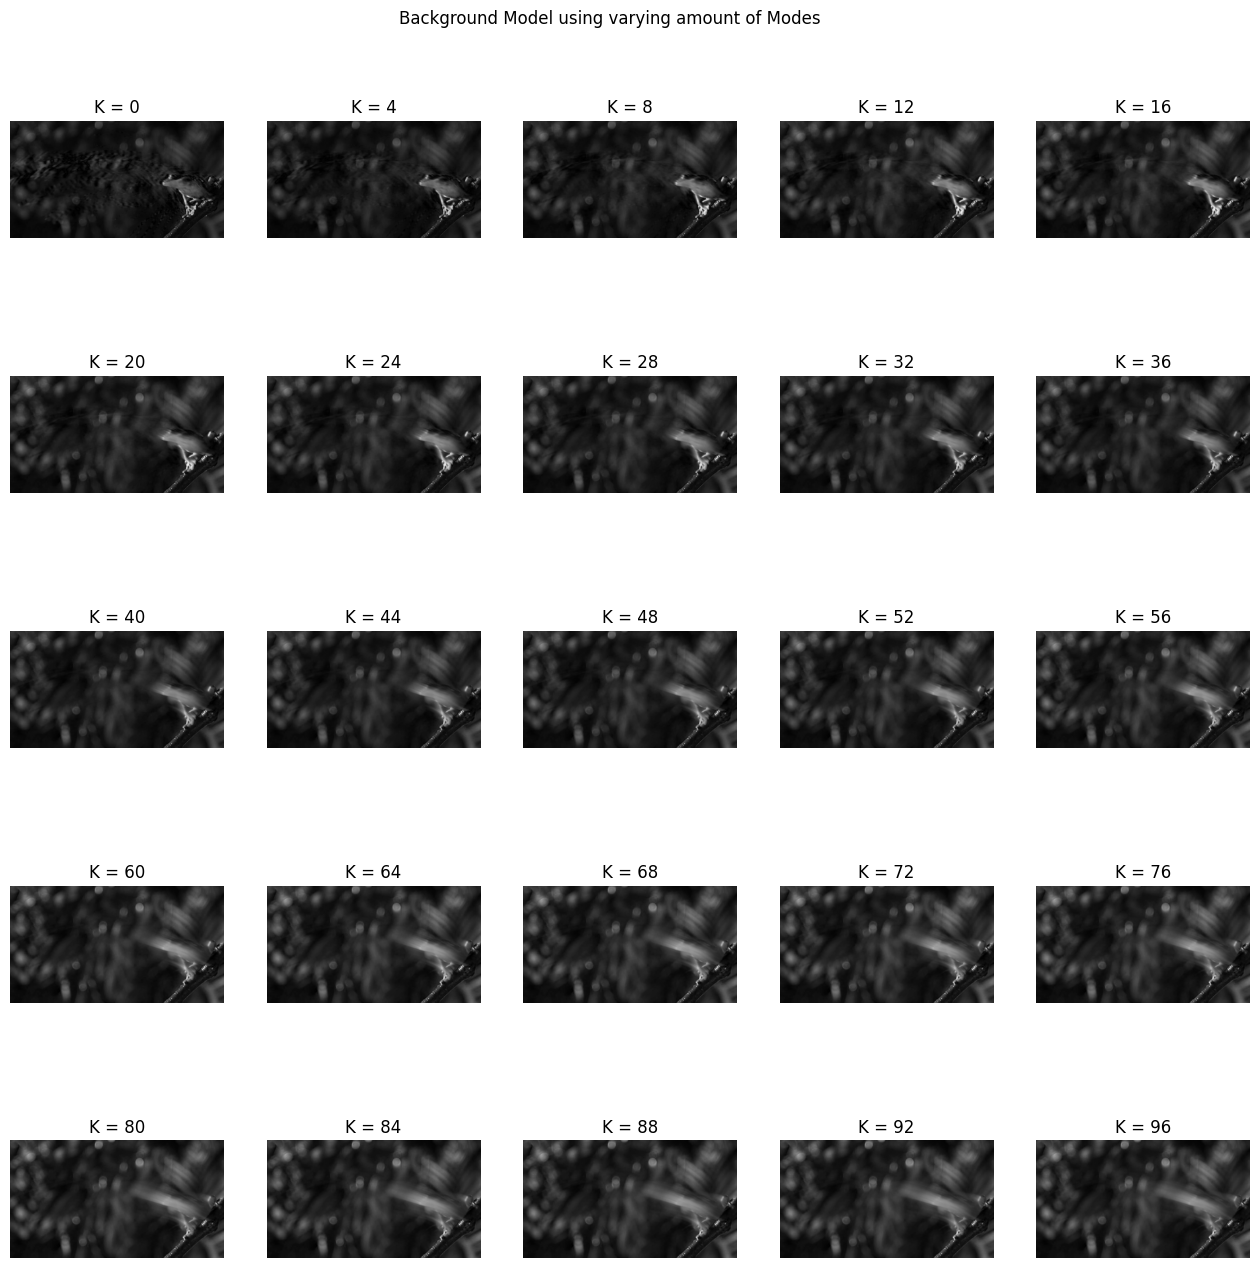

In [6]:
fig, axes = plt.subplots(5, 5, figsize=(16, 16))
axes = axes.flatten()

idx = 0
for k in range(K):
    bg += modes[k, :, :]
    if k % 4 == 0:
        if idx >= len(axes):
            continue
        axes[idx].axis("off")
        axes[idx].imshow(bg / (k + 1))
        axes[idx].set_title(f"K = {k}")
        idx += 1
plt.suptitle("Background Model using varying amount of Modes", y=0.92)
plt.show()

We plot the background:

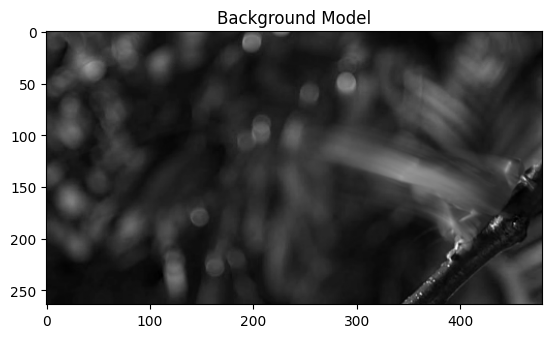

In [7]:
bg /= K
plt.imshow(bg)
plt.title("Background Model")
plt.show()

And an example frame:

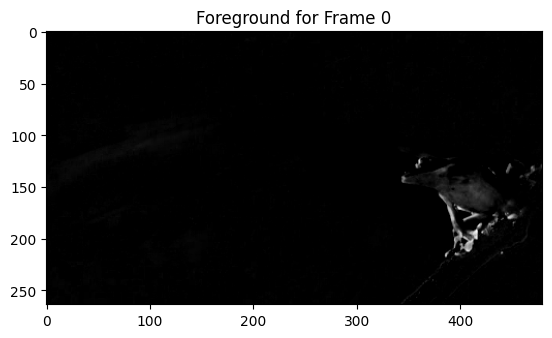

In [8]:
tmp = get_video()
img = tmp[0, :, :]
fg = (img - bg).clip(0, 1)
plt.title("Foreground for Frame 0")
plt.imshow(fg)
plt.show()

## Results
Time to get some quanitative (and qualitative) results! We will examine mean intersection over union (`mIoU`) and `F1` score, respectively. These metrics are a function of the threshold we choose for deciding foreground vs background. 

We can also visualize the eigenvalues, modes, and dynamics of our video computed from DMD.

In [9]:
video_removed = get_video_removed(tmp, bg).clip(0, 1)
gt = get_gt_video()

video_removed.shape, gt.shape

((279, 264, 480), (279, 264, 480))

We compute `mIoU` and `F1` as a function of threshold value, takes a bit to run.

In [10]:
thresholds = np.linspace(0, 1, 10)

mious = []
f1s = []
for thresh in thresholds:
    mious.append(calc_miou(video_removed, gt, thresh=thresh))
    f1s.append(calc_f1(video_removed, gt, thresh=thresh))

We plot the results:

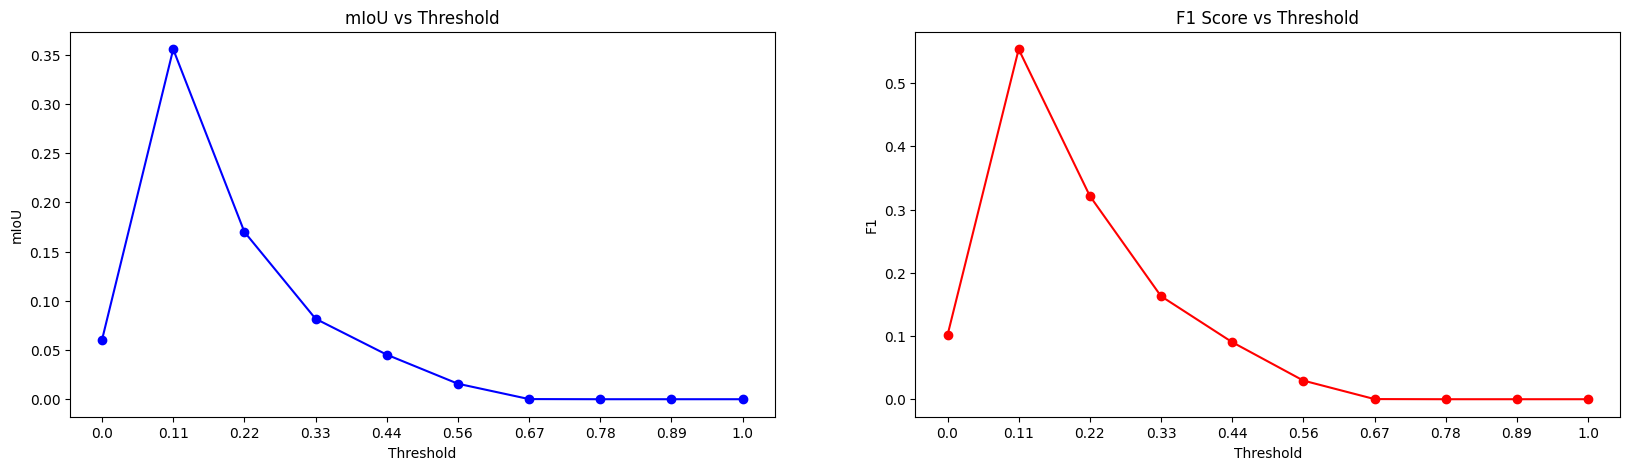

In [11]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.plot(mious, "bo-")
plt.title("mIoU vs Threshold")
plt.ylabel("mIoU")
plt.xlabel("Threshold")
plt.xticks(range(len(thresholds)), np.round(thresholds, 2))

plt.subplot(1, 2, 2)
plt.plot(f1s, "ro-")
plt.title("F1 Score vs Threshold")
plt.ylabel("F1")
plt.xlabel("Threshold")
plt.xticks(range(len(thresholds)), np.round(thresholds, 2))

plt.show()

We now plot the video with the background removed. You can try playing with the threshold, keep in mind that it shoud remain inside $[0,1]$:

In [17]:
# show binary output or not, if False thresh doesn't matter
use_mask = True
play_video_removed(bg, mask=use_mask, thresh=0.11)

We print the distances from the unit circle of the first 6 eigenvalues in `dmd.eigs`, and plot all.

Eigenvalue (0.6064426244929078+0.5632001342623646j): distance from unit circle  0.17237
Eigenvalue (0.6064426244929078-0.5632001342623646j): distance from unit circle  0.17237
Eigenvalue (0.6947350524316267+0.5389391183515608j): distance from unit circle  0.12073
Eigenvalue (0.6947350524316267-0.5389391183515608j): distance from unit circle  0.12073
Eigenvalue (0.6499975607258971+0.45171689167728757j): distance from unit circle  0.20845
Eigenvalue (0.6499975607258971-0.45171689167728757j): distance from unit circle  0.20845


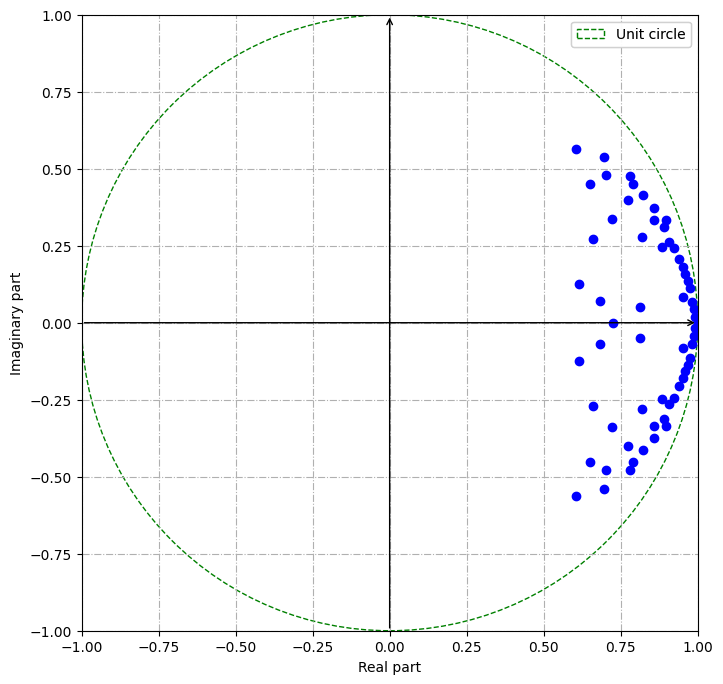

In [33]:
for idx, eig in enumerate(dmd.eigs[:6]):
    print(
        f"Eigenvalue {eig}: distance from unit circle {np.abs(np.abs(eig)-1): .5f}"
    )

plot_eigs(dmd, show_axes=True, show_unit_circle=True)

We also plot the first 6 modes and dynamics. The modes are hard to disentangle when SVD rank is larger than 3 but we can see the slow varying dynamic, which is our background mode!

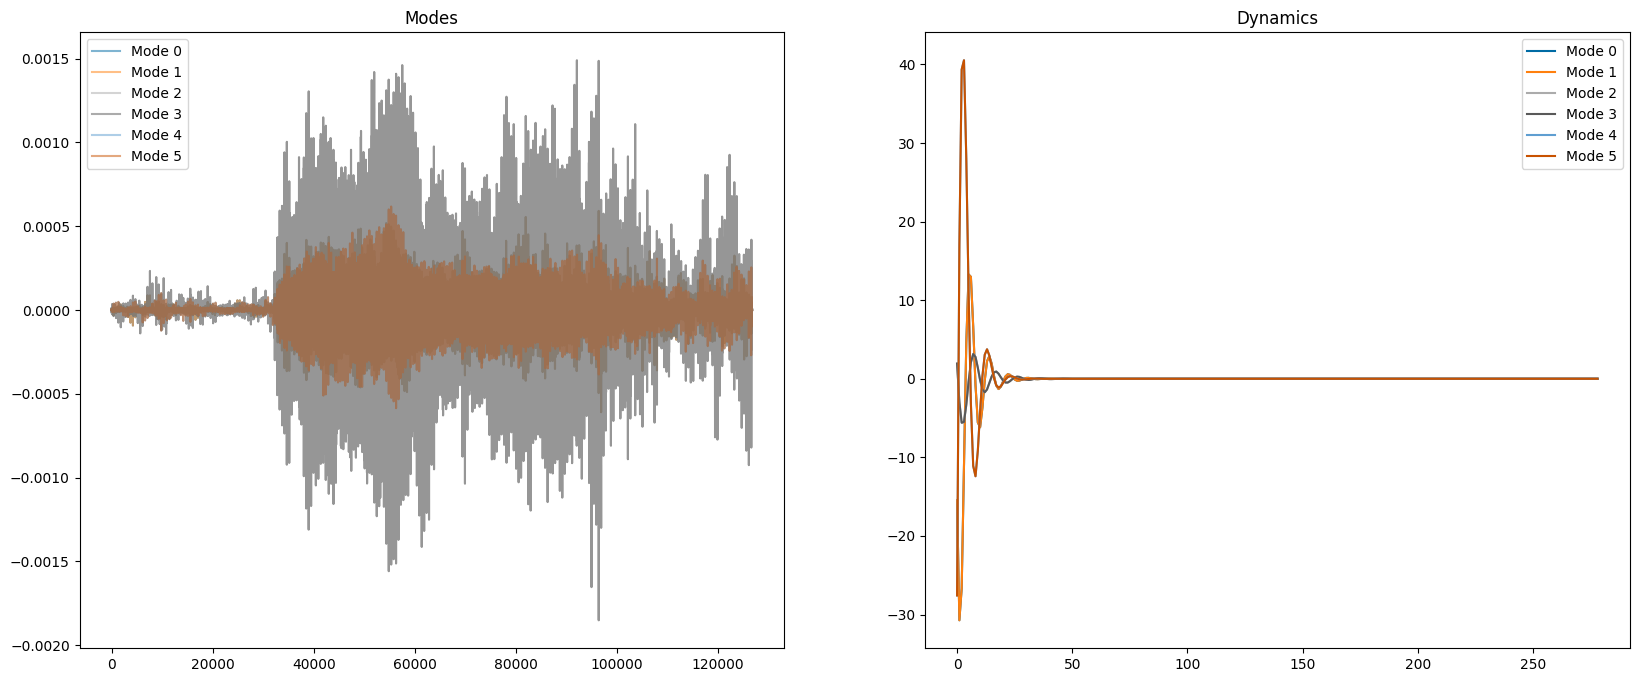

In [34]:
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
for idx, mode in enumerate(dmd.modes.T[:6]):
    plt.plot(mode.real, alpha=0.5, label=f"Mode {idx}")
plt.title("Modes")
plt.legend()

plt.subplot(1, 2, 2)
for idx, dynamic in enumerate(dmd.dynamics[:6]):
    plt.plot(dynamic.real, label=f"Mode {idx}")
plt.title("Dynamics")
plt.legend()

plt.show()